# Agent Observer · 运行与结果看板
按顺序运行全部单元格。默认运行 7 晚演示场景；修改配置即可运行 180 晚练习或正式赛预演。

本 Notebook 调用原有 `local_runner.main`、评分器与回放生成器，不修改原始文件或科学计算逻辑。只读监测层从智能体收到的公开快照提取进度，每约 0.5 秒刷新。监测有少量耗时，计入原有墙钟预算；接近预算上限时可能影响完成的决策数。

需要 Python ≥ 3.9、Jupyter/IPython、pandas、matplotlib。缺少包时，在当前内核运行 `%pip install ipykernel pandas matplotlib`。默认确定性智能体不需要模型 API。

In [1]:
from pathlib import Path
import sys, json, time, subprocess, os, html, uuid
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, FileLink

# 从项目根目录打开本文件；若内核工作目录在其他位置，在这里指定绝对路径。
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "local_runner.py").is_file():
    raise FileNotFoundError("请把 PROJECT_ROOT 设置为 agent-observer-starter-kit 的绝对路径")
SCENARIO_NAME = "dev-reference"  # 可选：demo-week / dev-reference / finals-preview
SCENARIO = PROJECT_ROOT / "scenarios" / SCENARIO_NAME
AGENT = PROJECT_ROOT / "agent" / "minimal_agent.py"
WALLCLOCK_SECONDS = 900
AGENT_PYTHON = sys.executable
assert (SCENARIO / "config" / "workflow_config.json").is_file(), SCENARIO
assert AGENT.is_file(), AGENT
assert WALLCLOCK_SECONDS > 0
print(f"场景：{SCENARIO.name} | 内核：{sys.executable}")


场景：dev-reference | 内核：c:\Program Files\Python310\python.exe


## 运行并实时观察
每次运行创建独立的 `notebook_runs/场景_时间_编号/`，保留历史结果。进度百分比表示模拟时隙位置，不是运行耗时预测；完成天区数也不等于巡天时间进度。

使用内核的“中断”按钮停止本次运行，会清理运行器及智能体子进程。中断时原运行器可能尚未生成评分文件，可以重新运行本单元格。不要直接关闭内核来停止。

In [2]:
# 包装仅存在于本次子进程；原始 Python 文件保持不变。
MONITOR_SOURCE = r"""
import json, os, sys, time
from pathlib import Path
import local_runner
progress_path = Path(sys.argv[1])
# Windows Python needs SystemRoot to initialize its random-number provider.
# Preserve only OS runtime paths, without inheriting model credentials.
original_build_env = local_runner.build_agent_env
def monitored_build_env(*args, **kwargs):
    env, keys = original_build_env(*args, **kwargs)
    if os.name == "nt":
        for key in ("SystemRoot", "WINDIR"):
            if key in os.environ:
                env[key] = os.environ[key]
    return env, keys
local_runner.build_agent_env = monitored_build_env
OriginalProvider = local_runner.LocalAgentProcess
class MonitoredProvider(OriginalProvider):
    _last_progress = 0.0
    def __call__(self, snapshot, deadline_monotonic):
        now = time.monotonic()
        if now - self._last_progress >= 0.3:
            payload = {"cursor": snapshot["cursor"],
                       "sequence": snapshot["decision_sequence"],
                       "completed": len(snapshot["progress"]["completed_tile_ids"])}
            try:
                temporary = progress_path.with_suffix(".tmp")
                temporary.write_text(json.dumps(payload), encoding="utf-8")
                os.replace(temporary, progress_path)
            except OSError:
                pass  # 可视化写入失败不干扰决策
            self._last_progress = now
        return super().__call__(snapshot, deadline_monotonic)
local_runner.LocalAgentProcess = MonitoredProvider
raise SystemExit(local_runner.main(sys.argv[2:]))
"""

slots = pd.read_csv(SCENARIO / "outputs/reference/slots.csv")
tiles = pd.read_csv(SCENARIO / "outputs/reference/tiles.csv")
slot_positions = {str(v): i for i, v in enumerate(slots.slot_id)}
RUN_DIR = PROJECT_ROOT / "notebook_runs" / (
    SCENARIO.name + "_" + datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:6])
RUN_DIR.mkdir(parents=True)
(RUN_DIR / "notebook_config.json").write_text(json.dumps({
    "scenario": str(SCENARIO), "agent": str(AGENT), "wallclock": WALLCLOCK_SECONDS,
    "python": AGENT_PYTHON}, indent=2), encoding="utf-8")
progress_file = RUN_DIR / "progress.json"
runner_log = RUN_DIR / "runner.log"
command = [sys.executable, "-u", "-c", MONITOR_SOURCE, str(progress_file),
           "--scenario", str(SCENARIO), "--agent", str(AGENT),
           "--python", AGENT_PYTHON, "--wallclock", str(WALLCLOCK_SECONDS), "--out", str(RUN_DIR)]
view = display(HTML("正在初始化环境……"), display_id=True)
started = time.monotonic()
latest = {}
def render_progress(status, finished=False):
    cursor = latest.get("cursor", {})
    position = slot_positions.get(cursor.get("slot_id"), 0)
    fraction = 1.0 if finished else position / max(len(slots), 1)
    elapsed = time.monotonic() - started
    view.update(HTML(f"""<div style='padding:18px;border:1px solid #aaa;border-radius:12px'>
    <h3>Agent Observer · {html.escape(SCENARIO.name)}</h3>
    <b>{html.escape(status)}</b> · 已耗时 {elapsed:.1f} 秒<br>
    <progress value='{fraction}' max='1' style='width:100%;height:24px'></progress>
    <div>巡天时间进度 {fraction:.1%} · 共 {len(slots)} 个时隙</div>
    <div>夜晚 {html.escape(str(cursor.get('night_id', '—')))} · 当前决策序号 {latest.get('sequence', 0)}
    · 已完成天区 {latest.get('completed', 0)} / {len(tiles)}</div>
    <small>模拟时间（UTC）：{html.escape(str(cursor.get('timestamp_utc', '—')))}</small></div>"""))

with runner_log.open("w", encoding="utf-8") as log_handle:
    proc = subprocess.Popen(command, cwd=PROJECT_ROOT, stdout=log_handle,
                            stderr=subprocess.STDOUT, start_new_session=(os.name != "nt"))
    try:
        while proc.poll() is None:
            try:
                latest = json.loads(progress_file.read_text(encoding="utf-8"))
            except (OSError, ValueError):
                pass
            render_progress("运行中；决策结束后自动评分并生成回放")
            time.sleep(0.5)
    finally:
        if proc.poll() is None:
            if os.name == "nt":
                subprocess.run(["taskkill", "/F", "/T", "/PID", str(proc.pid)], capture_output=True)
            else:
                import signal
                os.killpg(proc.pid, signal.SIGTERM)
            proc.wait(timeout=15)
            render_progress("已中断；结果可能不完整")

if (RUN_DIR / "score_report.json").exists():
    report = json.loads((RUN_DIR / "score_report.json").read_text(encoding="utf-8"))
    latest["completed"] = len(report["completion"]["completed_tiles"])
    render_progress("结束：" + report["termination_reason"], report["termination_reason"] == "survey_complete")
if proc.returncode != 0:
    print(runner_log.read_text(encoding="utf-8", errors="replace")[-6000:])
    raise RuntimeError(f"运行器退出码 {proc.returncode}，请查看 {RUN_DIR / 'agent.log'}")
print("结果目录：", RUN_DIR)


结果目录： E:\codex_work\agent-observer-starter-kit\notebook_runs\dev-reference_20260929_151533_c14352


## 权威评分与结果图
以下数据直接读取原评分器的 `score_report.json`。得分构成包括科学分、观测模式奖励、请求奖励、覆盖奖励、异常上报奖励和各项罚分。`coverage_evenness` 是无量纲指标，不作为额外得分相加。

完成曲线统计首次完成的不同天区；正式赛重复观测只取每块天区的最高分，因此这里不把逐次曝光分数累加成总分。

,场景,结束原因,总分,完成天区,遗漏必做天区,覆盖均匀性,已提交动作（含上报）,计入预算的秒数
0,dev-reference,survey_complete,12287.478365,64,0,1.0,7943,66.656


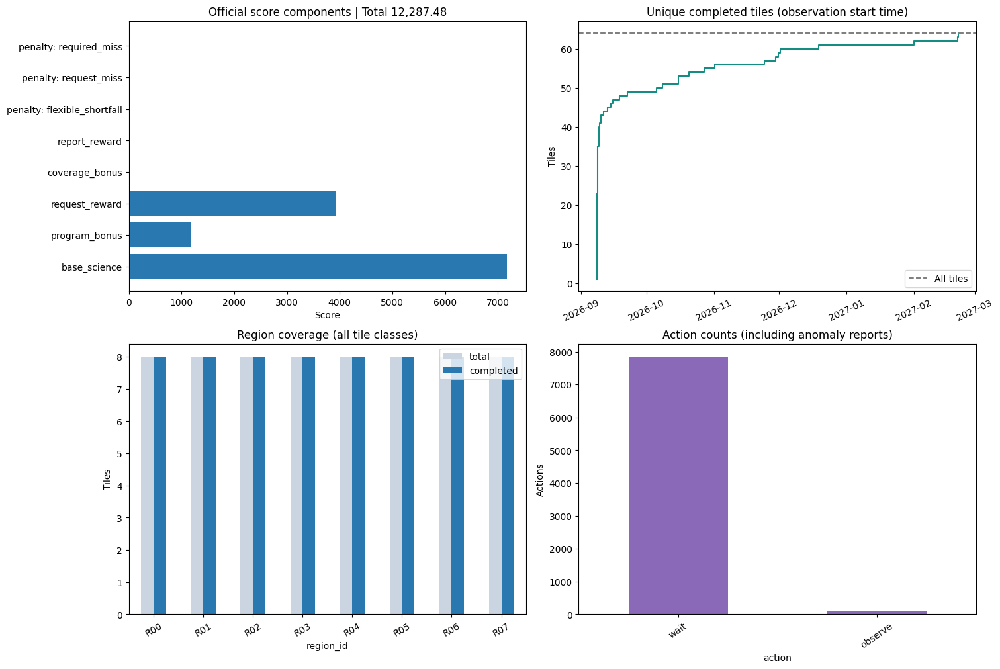

得分构成核对差值（允许舍入误差）： -0.0


In [3]:
# 查看历史运行时，把 RUN_DIR 改为已有结果目录，然后从此单元格继续。
config = json.loads((RUN_DIR / "notebook_config.json").read_text(encoding="utf-8"))
result_scenario = Path(config["scenario"])
report = json.loads((RUN_DIR / "score_report.json").read_text(encoding="utf-8"))
workflow_result = json.loads((RUN_DIR / "workflow_result.json").read_text(encoding="utf-8"))
actions = pd.DataFrame(report["actions"])
decisions = pd.read_csv(RUN_DIR / "decisions.csv")
tiles = pd.read_csv(result_scenario / "outputs/reference/tiles.csv")
score = report["score"]
completion = report["completion"]
display(pd.DataFrame([{
    "场景": result_scenario.name, "结束原因": report["termination_reason"],
    "总分": score["total"], "完成天区": len(completion["completed_tiles"]),
    "遗漏必做天区": len(completion["required_missing"]),
    "覆盖均匀性": score.get("coverage_evenness", 0),
    "已提交动作（含上报）": workflow_result["committed_action_count"],
    "计入预算的秒数": workflow_result["accounted_wallclock_seconds"]}]))

parts = {k: score.get(k, 0) for k in
         ["base_science", "program_bonus", "request_reward", "coverage_bonus", "report_reward"]}
parts.update({"penalty: " + k: -v for k, v in score["penalties"].items()})
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
ax = axes[0, 0]
ax.barh(list(parts), list(parts.values()), color=["#2979b0" if v >= 0 else "#d35b59" for v in parts.values()])
ax.set_title(f"Official score components | Total {score['total']:,.2f}")
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Score")

ax = axes[0, 1]
if not actions.empty:
    actions["time_utc"] = pd.to_datetime(actions["start_utc"], utc=True)
    finished = actions.loc[actions["outcome"].eq("completed")].drop_duplicates("tile_id")
    ax.step(finished["time_utc"], range(1, len(finished)+1), where="post", color="#168d82")
    ax.axhline(len(tiles), linestyle="--", color="gray", label="All tiles")
    ax.legend()
ax.set_title("Unique completed tiles (observation start time)")
ax.set_ylabel("Tiles")
ax.tick_params(axis="x", rotation=25)

ax = axes[1, 0]
coverage = tiles.assign(completed=tiles.tile_id.isin(completion["completed_tiles"]))
regional = coverage.groupby("region_id").agg(total=("tile_id", "size"), completed=("completed", "sum"))
regional.plot.bar(ax=ax, color=["#cbd5e1", "#2979b0"], rot=30)
ax.set_title("Region coverage (all tile classes)")
ax.set_ylabel("Tiles")

ax = axes[1, 1]
if not actions.empty:
    actions["action"].value_counts().plot.bar(ax=ax, color="#8a69b8", rot=35)
ax.set_title("Action counts (including anomaly reports)")
ax.set_ylabel("Actions")
fig.savefig(RUN_DIR / "dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("得分构成核对差值（允许舍入误差）：", round(sum(parts.values()) - score["total"], 6))


## 决策明细、请求与异常
可用 `ACTION_FILTER` 筛选动作，例如 `observe`、`wait`、`report_instrument_failure`；留空显示全部。这里只展示前 50 行，完整数据在 CSV 和报告中。

In [4]:
ACTION_FILTER = ""
selected = decisions if not ACTION_FILTER else decisions[decisions.action.eq(ACTION_FILTER)]
display(selected.head(50))
print("观测请求")
display(pd.DataFrame(report.get("requests", [])))
print("异常报告结算")
display(report.get("reports", {}))
print("遗漏的必做天区：", completion["required_missing"])
print("各区域 FLEXIBLE 缺额：", completion["flexible_shortfall"])


,decision_id,slot_id,action,tile_id,program,request_id,reason
0,D000001,N20260907-S001,observe,T00057,BRIGHT,NaN,highest public current-snapshot estimate
1,D000002,N20260907-S001,observe,T00050,DARK,NaN,highest public current-snapshot estimate
2,D000003,N20260907-S002,observe,T00058,BRIGHT,NaN,highest public current-snapshot estimate
3,D000004,N20260907-S003,observe,T00049,DARK,NaN,highest public current-snapshot estimate
4,D000005,N20260907-S004,observe,T00053,DARK,NaN,highest public current-snapshot estimate
5,D000006,N20260907-S005,observe,T00062,DARK,RQ0001,highest public current-snapshot estimate
6,D000007,N20260907-S006,observe,T00045,BRIGHT,NaN,highest public current-snapshot estimate
7,D000008,N20260907-S006,observe,T00059,DARK,NaN,highest public current-snapshot estimate
8,D000009,N20260907-S007,observe,T00046,BRIGHT,NaN,highest public current-snapshot estimate
9,D000010,N20260907-S008,observe,T00060,BRIGHT,NaN,highest public current-snapshot estimate


观测请求


,feasible_tile_count,penalty,request_id,required_tile_count,reward,satisfied_tile_count,status
0,NaN,0.0,RQ0001,3,420.0,3,completed
1,NaN,0.0,RQ0002,1,140.0,1,completed
2,NaN,0.0,RQ0003,1,140.0,1,completed
3,NaN,0.0,RQ0004,1,140.0,1,completed
4,NaN,0.0,RQ0005,1,140.0,1,completed
5,NaN,0.0,RQ0006,1,140.0,1,completed
6,NaN,0.0,RQ0007,1,140.0,1,completed
7,NaN,0.0,RQ0008,3,420.0,3,completed
8,NaN,0.0,RQ0009,1,140.0,1,completed
9,NaN,0.0,RQ0010,1,140.0,1,completed


异常报告结算


{'fault_acknowledged_event_ids': [],
 'fault_correct_reports': 0,
 'fault_misreports': 0,
 'tag_settlements': []}

遗漏的必做天区： []
各区域 FLEXIBLE 缺额： {'R00': 0, 'R01': 0, 'R02': 0, 'R03': 0, 'R04': 0, 'R05': 0, 'R06': 0, 'R07': 0}


## 原版交互回放与文件
下方嵌入原项目生成的 HTML 回放，可逐步查看夜晚、天气与观测决策。如果 Notebook 前端阻止脚本或显示空白，请将 Notebook 标记为可信，或直接用浏览器打开结果目录里的 `decision_replay.html`。

In [5]:
replay = RUN_DIR / "decision_replay.html"
if replay.is_file():
    replay_html = replay.read_text(encoding="utf-8")
    display(HTML('<iframe sandbox="allow-scripts" style="width:100%;height:820px;border:0" srcdoc="'
                 + html.escape(replay_html, quote=True) + '"></iframe>'))
else:
    print("回放未生成，请查看 runner.log。")
for name in ["decision_replay.html", "dashboard.png", "decisions.csv", "score_report.json", "workflow_result.json", "agent.log", "runner.log"]:
    path = RUN_DIR / name
    if path.exists():
        try:
            display(FileLink(str(path.relative_to(Path.cwd()))))
        except ValueError:
            print(path)


c:\Program Files\Python310\lib\site-packages\IPython\core\display.py:475: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


e:\codex_work\agent-observer-starter-kit\notebook_runs\dev-reference_20260929_151533_c14352\decision_replay.html

e:\codex_work\agent-observer-starter-kit\notebook_runs\dev-reference_20260929_151533_c14352\dashboard.png

e:\codex_work\agent-observer-starter-kit\notebook_runs\dev-reference_20260929_151533_c14352\decisions.csv

e:\codex_work\agent-observer-starter-kit\notebook_runs\dev-reference_20260929_151533_c14352\score_report.json

e:\codex_work\agent-observer-starter-kit\notebook_runs\dev-reference_20260929_151533_c14352\workflow_result.json

e:\codex_work\agent-observer-starter-kit\notebook_runs\dev-reference_20260929_151533_c14352\agent.log

e:\codex_work\agent-observer-starter-kit\notebook_runs\dev-reference_20260929_151533_c14352\runner.log

## 可选：重新评分与打包
默认不开启。重新评分调用原有接口并保留运行时的结束原因；打包调用原打包器生成 ZIP。这里不执行网络提交。


In [6]:
RESCORE = False
PACK_AGENT = False
if RESCORE:
    subprocess.run([sys.executable, str(PROJECT_ROOT / "score_decisions.py"),
                    "--scenario", str(result_scenario), "--decisions", str(RUN_DIR / "decisions.csv"),
                    "--out", str(RUN_DIR / "score_report_rechecked.json")], cwd=PROJECT_ROOT, check=True)
    checked = json.loads((RUN_DIR / "score_report_rechecked.json").read_text(encoding="utf-8"))
    assert checked["score"] == report["score"], "重新评分与原报告不一致"
    print("重新评分一致。")
if PACK_AGENT:
    subprocess.run([sys.executable, str(PROJECT_ROOT / "pack_agent.py")], cwd=PROJECT_ROOT, check=True)
